# NAIP imagery at the Cheyenne River stream gauges

Pull a NAIP tile centered on a USGS stream gauge and look for **cottonwood gallery forest**
along the channel. Galleries are narrow, so the 60 cm NAIP resolution matters here in a way
that HLS (30 m) cannot match.

- **Input**: `data/cheyenne_corridor_aoi.gpkg`, layer `usgs_gauges`, from
  [`00_Study_Area-Cottonwoods.ipynb`](../00_Study_Area-Cottonwoods.ipynb).
- **Imagery**: NAIP via the Microsoft Planetary Computer STAC API - 4-band (R, G, B, NIR) COGs,
  anonymous access, no AWS credentials and no requester-pays egress.
- **Scope**: one gauge, one tile. The loop over all gauges and the actual classification come
  later, in notebooks 03 and 04.

Two things to know about the imagery: the PC catalog currently ends at 2023, so 2022 is the
newest South Dakota epoch available; and NAIP here is EPSG:26913 (NAD83 / UTM 13N), which is a
*different datum* from the EPSG:32613 used by the VBET pipeline - reproject, never assume.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.windows import from_bounds
import planetary_computer
import pystac_client

# Walk up to the repo root so this works from anywhere, not just notebooks/PineRidge/.
def _resolve_data_dir():
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / ".git").exists() or (p / "environment.yml").is_file():
            return p / "data"
    return Path("../../data")

DATA_DIR = _resolve_data_dir()
print(DATA_DIR)
# --- configura≈ztion ---
CORRIDOR_GPKG = DATA_DIR / "cheyenne_corridor_aoi.gpkg"  # written by notebook 00
GAUGE_ID      = "06403700"   # Cheyenne R at Red Shirt - the REFERENCE_GAUGE in notebook 00
BUFFER_M      = 5000         # half-width of the chip -> a 10 km box, ~16,600 px sq at 60 cm
NAIP_YEAR     = 2022         # None -> use the most recent epoch available
NDVI_CANOPY   = 0.4          # first-pass threshold for "this is woody canopy"

print("Ready.")

/Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/esiil/Public-Observing-Unci-Maka/data
Ready.


In [2]:
# The corridor gauge layer is everything NLDI returned for the Cheyenne. Most of it is not
# stream gauges: 15-digit site ids are groundwater wells and miscellaneous sites with no
# discharge record. The 8-digit ids are the surface-water stations we actually want.
gauges = gpd.read_file(CORRIDOR_GPKG, layer="usgs_gauges")
gauges["site_no"] = gauges["identifier"].str.replace("USGS-", "", regex=False)
gauges = gauges[gauges["site_no"].str.len() == 8].copy()
print(f"{len(gauges)} surface-water gauges in the corridor")

gauge = gauges.loc[gauges["site_no"] == GAUGE_ID]
if gauge.empty:
    raise ValueError(f"{GAUGE_ID} is not a corridor gauge. Available: {sorted(gauges.site_no)}")
gauge_pt = gauge.geometry.iloc[0]  # EPSG:4326
print(f"Gauge {GAUGE_ID}: {gauge_pt.y:.5f}, {gauge_pt.x:.5f}")

48 surface-water gauges in the corridor
Gauge 06403700: 43.67241, -102.89213


## Find the NAIP scenes over this gauge

`sign_inplace` fetches an anonymous SAS token and rewrites each asset href with it. The tokens
are short-lived (~45 min) - if a read below returns HTTP 403, re-run this cell to refresh them.

In [3]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
items = list(catalog.search(collections=["naip"],
                            intersects=gauge_pt.__geo_interface__).item_collection())

# Every NAIP epoch over this gauge. This list is the input for change detection later on.
epochs = pd.DataFrame(
    [{"year": int(i.properties["naip:year"]), "gsd_m": i.properties["gsd"], "id": i.id}
     for i in items]
).sort_values("year", ignore_index=True)
print(epochs.to_string(index=False))

if NAIP_YEAR is None:
    item = max(items, key=lambda i: int(i.properties["naip:year"]))
else:
    match = [i for i in items if int(i.properties["naip:year"]) == NAIP_YEAR]
    if not match:
        raise ValueError(f"No NAIP for {NAIP_YEAR} here. Available: {list(epochs.year)}")
    item = match[0]

year = int(item.properties["naip:year"])
print(f"\nUsing {item.id}")

 year  gsd_m                                       id
 2012    1.0   sd_m_4310217_se_13_1_20120728_20121004
 2014    1.0   sd_m_4310217_se_13_1_20140726_20141113
 2016    0.6            sd_m_4310217_se_13_h_20160917
 2018    0.6 sd_m_4310217_se_13_060_20180829_20181212
 2020    0.6          sd_m_4310217_se_13_060_20200722
 2021    0.6          sd_m_4310217_se_13_060_20210824
 2022    0.6          sd_m_4310217_se_13_060_20220713

Using sd_m_4310217_se_13_060_20220713


In [4]:
# Read only the window we need straight out of the COG - no full-tile download.
with rio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"):
    with rio.open(item.assets["image"].href) as src:
        print(f"Bands: {src.count} | CRS: {src.crs} | Full tile: {src.width} x {src.height}")
        # Buffer in the image's own projected CRS so BUFFER_M is genuinely metres.
        pt = gpd.GeoSeries([gauge_pt], crs="EPSG:4326").to_crs(src.crs).iloc[0]
        left, bottom, right, top = pt.buffer(BUFFER_M).bounds
        window = from_bounds(left, bottom, right, top, transform=src.transform)
        tile = src.read(window=window)
        chip_transform = src.window_transform(window)
        chip_crs = src.crs

print(f"Chip: {tile.shape} ({tile.dtype})")

Bands: 4 | CRS: EPSG:26913 | Full tile: 9627 x 12872
Chip: (4, 11779, 9627) (uint8)


## The cottonwood signal

NAIP band order is R, G, B, NIR. Cottonwood galleries should read as a bright ribbon of high
NDVI tracking the channel, standing out sharply against the dry upland on either side.

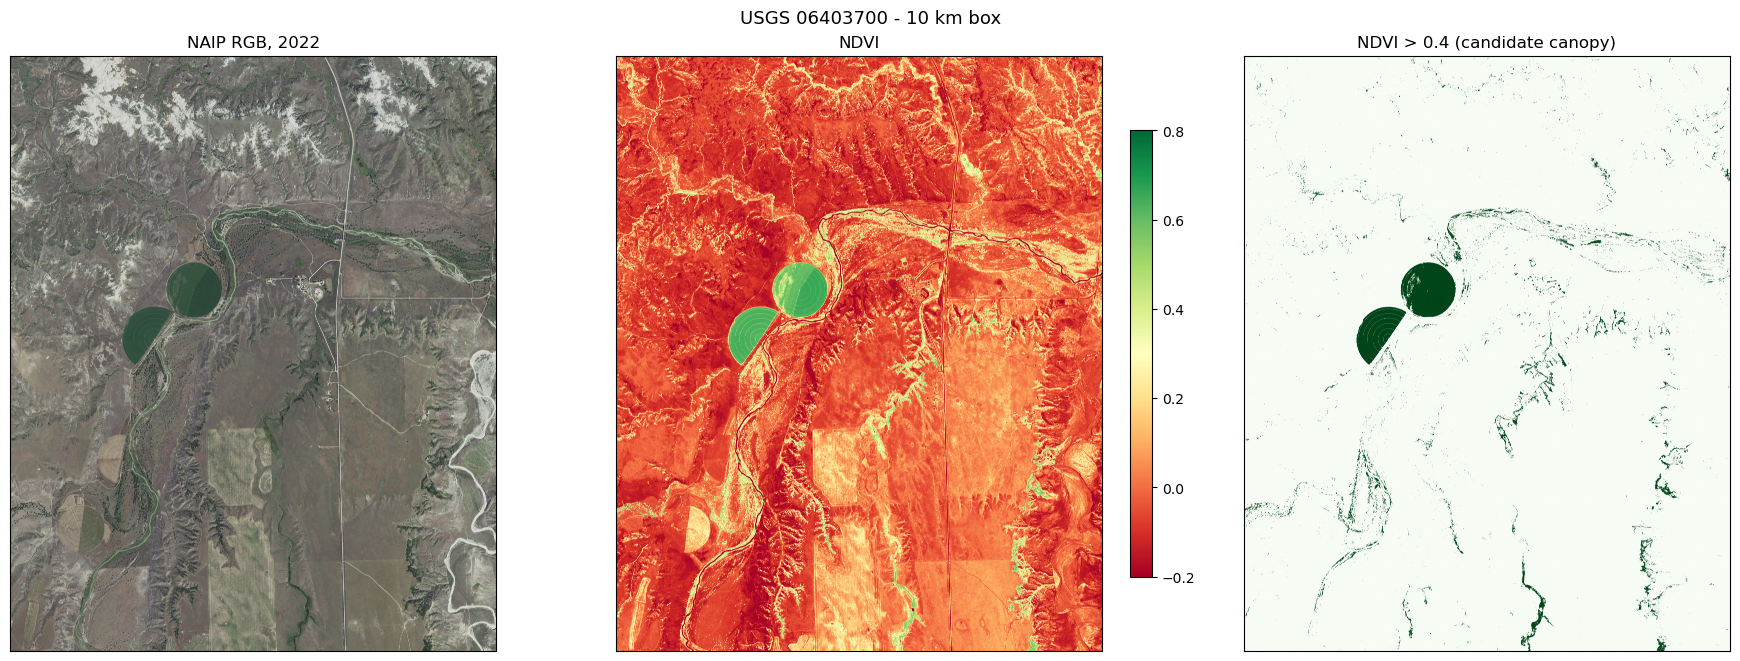

In [5]:
tile_f = tile.astype("float32")
red, nir = tile_f[0], tile_f[3]          # 0-based: 0=R, 1=G, 2=B, 3=NIR

den = nir + red
ndvi = np.where(den == 0, np.nan, (nir - red) / den)
rgb = np.moveaxis(tile[:3], 0, -1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), constrained_layout=True)
axes[0].imshow(rgb)
axes[0].set_title(f"NAIP RGB, {year}")
im = axes[1].imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[1].set_title("NDVI")
fig.colorbar(im, ax=axes[1], shrink=0.75)
axes[2].imshow(ndvi > NDVI_CANOPY, cmap="Greens")
axes[2].set_title(f"NDVI > {NDVI_CANOPY} (candidate canopy)")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"USGS {GAUGE_ID} - {2 * BUFFER_M / 1000:.0f} km box", fontsize=13)
plt.show()

In [6]:
out_dir = DATA_DIR / "naip_chips"
out_dir.mkdir(parents=True, exist_ok=True)
out_tif = out_dir / f"naip_{GAUGE_ID}_{year}.tif"

with rio.open(out_tif, "w", driver="GTiff", height=tile.shape[1], width=tile.shape[2],
              count=tile.shape[0], dtype=tile.dtype, crs=chip_crs, transform=chip_transform,
              tiled=True, compress="LZW") as dst:
    dst.write(tile)

print(f"Wrote {out_tif}")

Wrote /Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/esiil/Public-Observing-Unci-Maka/data/naip_chips/naip_06403700_2022.tif
